# Multiple Linear Regression from Scratch

This notebook implements Multiple Linear Regression using NumPy without using scikit-learn.

Topics covered:

- Multiple feature datasets
- Single prediction using loops
- Vectorized implementation using np.dot()
- Cost Function
- Gradient Computation
- Gradient Descent

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

| Feature | Description        |
| ------- | ------------------ |
| x₁      | Size (sq ft)       |
| x₂      | Number of bedrooms |
| x₃      | Number of floors   |
| x₄      | Age of house       |


In [101]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])
print(f"X Shape: {X_train.shape}")
print(X_train)
print(f"y Shape: {y_train.shape}")
print(y_train)

X Shape: (3, 4)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,)
[460 232 178]


In [102]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}")

w_init shape: (4,)


In [103]:
def single_prediction(x , w , b):
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]
        p = p + p_i
    p = p + b
    return p


In [104]:
x_vec =  X_train[0 , :]
print(f"x_vec value: {x_vec}")
f_wb = single_prediction(x_vec, w_init, b_init)
print(f"prediction: {f_wb}")

x_vec value: [2104    5    1   45]
prediction: 459.9999976194083


In [105]:
def predict (x , w , b):
    p = np.dot(x , w) + b
    return p

In [106]:
x_vec = X_train[0 , :]
print(f"x_vec value: {x_vec}")
f_wb = predict(x_vec , w_init , b_init)
print(f"prediction: {f_wb}")

x_vec value: [2104    5    1   45]
prediction: 459.9999976194083


In [107]:
def compute_cost(x , y , w , b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(x[i] , w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)
    return cost

In [108]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [109]:
def gradient_descent(X ,y , w , b):
    m , n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        err = (np.dot(X[i] , w) + b) - y[i]
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [110]:
tmp_dj_db, tmp_dj_dw = gradient_descent(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: {tmp_dj_dw}')

dj_db at initial w,b: -1.6739251501955248e-06
dj_dw at initial w,b: [-2.72623577e-03 -6.27197263e-06 -2.21745578e-06 -6.92403391e-05]


In [111]:
def gradient_decent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in)  
    b = b_in
    
    for i in range(num_iters):
        dj_db,dj_dw = gradient_function(X, y, w, b)   
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
        if i<100000:   
            J_history.append( cost_function(X, y, w, b))
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history 

In [112]:
initial_w = np.zeros_like(w_init)
initial_b = 0.
iterations = 1000
alpha = 5.0e-7
w_final, b_final, J_hist = gradient_decent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, gradient_descent, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
b,w found by gradient descent: -0.00,[ 0.20396569  0.00374919 -0.0112487  -0.0658614 ] 
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


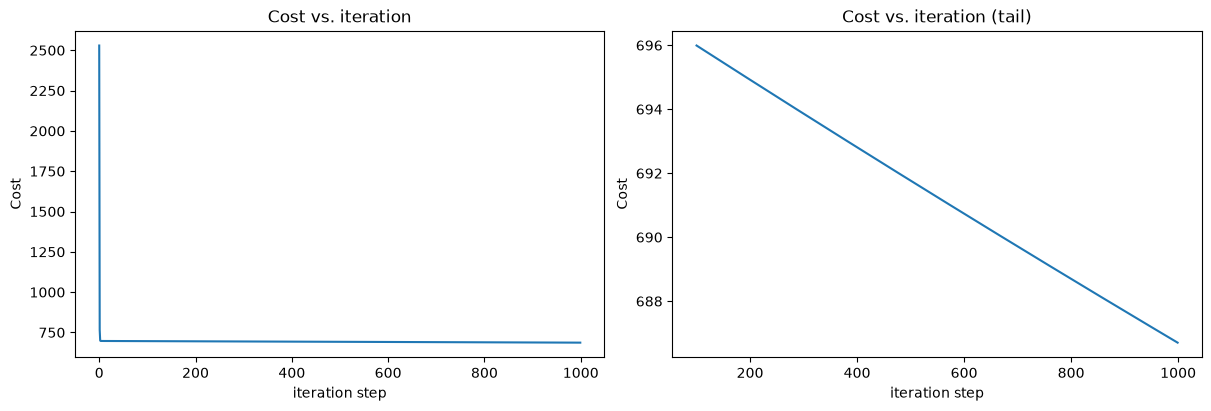

In [113]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

## Loop vs Vectorized Implementation

Loop implementation is easier to understand but slower.

Vectorized implementation using NumPy is much faster and preferred in practice.